Evaluación del Desempeño Operacional y Diagnóstico Hidrogeológico de los Acuíferos del Uruguay: Un Análisis Basado en Datos

Objetivo General
Evaluar el desempeño operacional de la gestión hídrica institucional, identificando cuellos de botella en la tramitación de expedientes, distribución de la carga de trabajo por oficinas regionales y características técnicas de las obras registradas
Desafío Institucional
Responder cuántos días tardan los expedientes en resolverse y cuáles regionales o técnicos presentan mayores retrasos o volumen de solicitudes
Valor del Análisis
Optimizar la gestión pública del agua, fundamentando decisiones basadas en datos para la redistribución de personal o reingeniería de procesos

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [107]:
df = pd.read_csv('C:/Users/tania/PycharmProjects/Python-Data-Analysis-GrupoA/data/raw/Base_de_datos_Python_GRUPO A.csv',sep=';')
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,55,"0,15","19,7",20,"37,5",NaN,14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,53,"0,15",9,25,29,NaN,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,31,"0,15",25,2,5,NaN,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,55,"0,15",20,28,"32,5",NaN,24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,64,"0,15","6,8","3,9","22,3",NaN,63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
df.drop(columns=["Caudal Máximo","Área de Cuenca","Área de Embalse","Volúmen de Embalse","Altura Máxima","Documento"], inplace=True)
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Tipo de acuifero,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,NaN,55,"0,15","19,7",20,"37,5",14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,NaN,53,"0,15",9,25,29,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,NaN,31,"0,15",25,2,5,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,NaN,55,"0,15",20,28,"32,5",24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,NaN,64,"0,15","6,8","3,9","22,3",63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
df.shape

(5700, 36)

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5700 entries, 0 to 5699
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Tipo de Solicitud              5159 non-null   str    
 1   Nro. GEX                       5157 non-null   str    
 2   Fecha Vencimiento              4700 non-null   str    
 3   Estado                         5159 non-null   str    
 4   Regional                       5157 non-null   str    
 5   Departamento                   5157 non-null   str    
 6   Tecnicos                       5142 non-null   str    
 7   Fecha de Solicitud             5158 non-null   str    
 8   Fecha de Resolución            4699 non-null   str    
 9   Fecha de Inscripción           4653 non-null   str    
 10  Caudal                         5113 non-null   str    
 11  Volumen                        5127 non-null   str    
 12  Uso                            5159 non-null   str    
 13 

In [111]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Mes Inicio,5123.0,6.718915,5.342711,1.0,1.0,10.0,12.00,12.0
Mes Final,5123.0,9.740582,3.386649,0.0,10.0,11.0,12.00,12.0
Horas x Año,5121.0,3128.130443,1866.384298,1.0,1600.0,2880.0,4320.00,9000.0
Id Solicitud,5159.0,249482.421012,6255.075576,237902.0,244274.5,249362.0,254852.50,261225.0
Codigo Cuencas de nivel 5,5152.0,37711.344332,18888.650444,10105.0,22600.0,27400.0,58171.25,68710.0
Sección y localidad catastral,3387.0,5.623561,13.541791,0.0,2.0,4.0,7.00,746.0
Codigo Cuencas de nivel 2,5152.0,37.194682,18.909617,10.0,22.0,27.0,58.00,68.0


In [112]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5695     True
5696     True
5697     True
5698     True
5699     True
Length: 5700, dtype: bool

In [113]:
df.duplicated().sum()

np.int64(540)

In [114]:
df

,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,Tipo de acuifero,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-00040200289-635.001,27/Mar/2011,Registrada,SALTO,SALTO,"Rodríguez, Jorge",18/set/2000,27/Mar/2001,NaN,...,NaN,55,"0,15","19,7",20,"37,5",14.0,Nueva,Autorización,7
1,Proyecto de Aprovechamiento,SGRH-00040200324-595.001,19/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,19/Oct/2000,25/Oct/2000,...,NaN,53,"0,15",9,25,29,18.0,Nueva,Autorización,4
2,Proyecto de Aprovechamiento,SGRH-00040200325-596.001,20/Oct/2010,Registrada,FRAY BENTOS,PAYSANDÚ,"Rodríguez, Jorge",10/Mar/2000,20/Oct/2000,27/Oct/2000,...,NaN,31,"0,15",25,2,5,18.0,Nueva,Autorización,4
3,Proyecto de Aprovechamiento,SGRH-00040200402-598.001,19/Oct/2010,Registrada,SAN JOSÉ,SAN JOSÉ,"Rodríguez, Jorge",11/Abr/2000,19/Oct/2000,25/Oct/2000,...,NaN,55,"0,15",20,28,"32,5",24.0,Nueva,Autorización,"2,5"
4,Proyecto de Aprovechamiento,SGRH-00040200414-609.001,10/Oct/2010,Registrada,SAN JOSÉ,CANELONES,"Rodríguez, Jorge",14/Abr/2000,10/Oct/2000,18/Oct/2000,...,NaN,64,"0,15","6,8","3,9","22,3",63.0,Nueva,Autorización,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


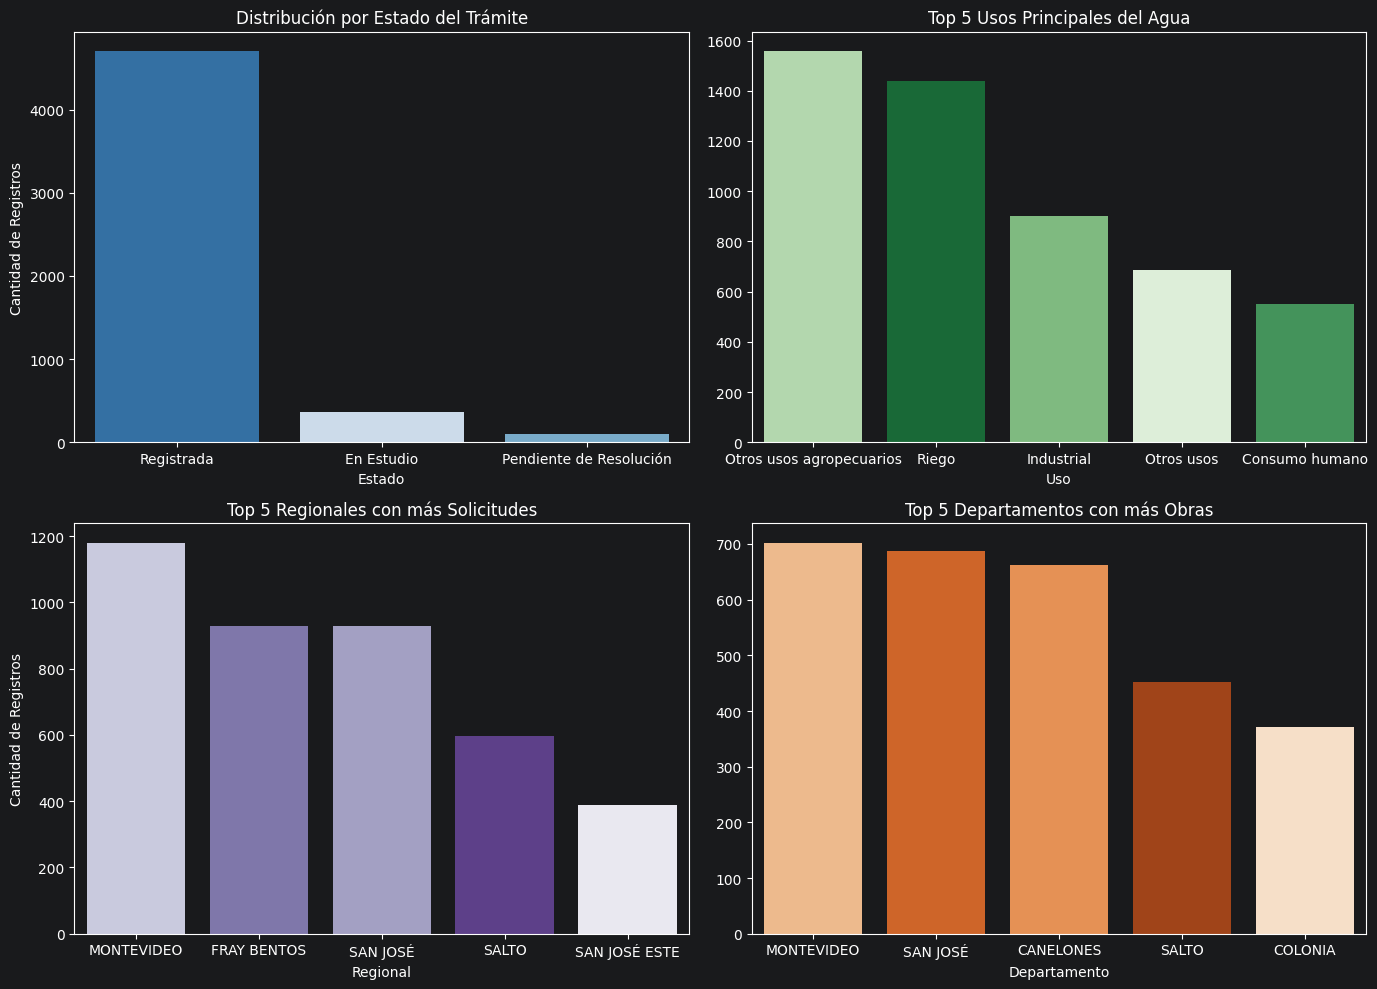

In [115]:
fig, axis = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(ax=axis[0, 0], data=df, x="Estado", order=df['Estado'].value_counts().index, hue="Estado", palette="Blues_r",legend=False)
axis[0, 0].set_title("Distribución por Estado del Trámite")
axis[0, 0].set_xlabel("Estado")
axis[0, 0].set_ylabel("Cantidad de Registros")
axis[0, 0].tick_params(axis='x')

top_usos = df['Uso'].value_counts().head(5).index
df_usos = df[df['Uso'].isin(top_usos)]
sns.countplot(ax=axis[0, 1], data=df_usos, x="Uso", order=top_usos, hue="Uso",palette="Greens_r",legend=False)
axis[0, 1].set_title("Top 5 Usos Principales del Agua")
axis[0, 1].set_xlabel("Uso")
axis[0, 1].set_ylabel(None)
axis[0, 1].tick_params(axis='x')

top_regionales = df['Regional'].value_counts().head(5).index
df_regionales = df[df['Regional'].isin(top_regionales)]
sns.countplot(ax=axis[1, 0], data=df_regionales, x="Regional", order=top_regionales, hue="Regional", palette="Purples_r",legend=False)
axis[1, 0].set_title("Top 5 Regionales con más Solicitudes")
axis[1, 0].set_xlabel("Regional")
axis[1, 0].set_ylabel("Cantidad de Registros")
axis[1, 0].tick_params(axis='x')

top_deptos = df['Departamento'].value_counts().head(5).index
df_deptos = df[df['Departamento'].isin(top_deptos)]
sns.countplot(ax=axis[1, 1], data=df_deptos, x="Departamento", order=top_deptos,hue="Departamento", palette="Oranges_r",legend=False)
axis[1, 1].set_title("Top 5 Departamentos con más Obras")
axis[1, 1].set_xlabel("Departamento")
axis[1, 1].set_ylabel(None)
axis[1, 1].tick_params(axis='x')

plt.tight_layout()

plt.savefig('panel_4_graficos_hidricos.png', dpi=300)

plt.show()

Este panel inicial ofrece una radiografía histórica y geográfica de las solicitudes. El Gráfico de Estado permite cuantificar cuántos trámites han concluido frente a los que siguen abiertos. El Top 5 de Usos identifica el motor de la demanda de agua (ej. agro, industrial, consumo), mientras que el Top 5 de Regionales y Departamentos geolocaliza la presión administrativa.
Se puede evaluar el alto porcentaje de usos clasificados como "otros usos", lo que se evalua como posibilidad de mejora

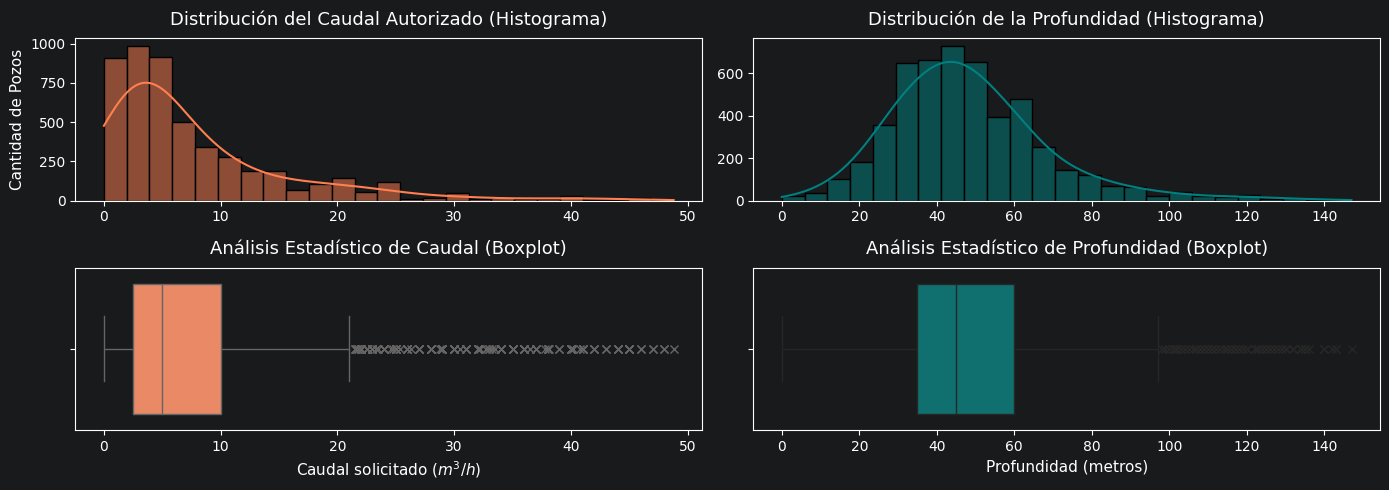

In [116]:
df['Caudal'] = pd.to_numeric(df['Caudal'].astype(str).str.replace(',', '.'), errors='coerce')
df['profundidad'] = pd.to_numeric(df['profundidad'].astype(str).str.replace(',', '.'), errors='coerce')

fig, axis = plt.subplots(2, 2, figsize=(14, 5))

df_caudal = df[df['Caudal'] < 50]
df_prof = df[df['profundidad'] < 150]


sns.histplot(ax=axis[0, 0], data=df_caudal, x="Caudal", bins=25, kde=True,
             kde_kws={'bw_adjust': 2}, color="coral")
axis[0, 0].set_title("Distribución del Caudal Autorizado (Histograma)", fontsize=13, pad=10)
axis[0, 0].set_xlabel(None) # Ocultamos etiqueta para no encimar con la fila de abajo
axis[0, 0].set_ylabel("Cantidad de Pozos", fontsize=11)

sns.histplot(ax=axis[0, 1], data=df_prof, x="profundidad", bins=25, kde=True,
             kde_kws={'bw_adjust': 2}, color="teal")
axis[0, 1].set_title("Distribución de la Profundidad (Histograma)", fontsize=13, pad=10)
axis[0, 1].set_xlabel(None)
axis[0, 1].set_ylabel(None)


sns.boxplot(ax=axis[1, 0], data=df_caudal, x="Caudal", color="coral", flierprops={"marker": "x"})
axis[1, 0].set_title("Análisis Estadístico de Caudal (Boxplot)", fontsize=13, pad=10)
axis[1, 0].set_xlabel("Caudal solicitado ($m^3/h$)", fontsize=11)

sns.boxplot(ax=axis[1, 1], data=df_prof, x="profundidad", color="teal", flierprops={"marker": "x"})
axis[1, 1].set_title("Análisis Estadístico de Profundidad (Boxplot)", fontsize=13, pad=10)
axis[1, 1].set_xlabel("Profundidad (metros)", fontsize=11)

plt.tight_layout()
plt.savefig('histogramas_y_boxplots.png', dpi=300)
plt.show()

El análisis conjunto del Histograma y el Boxplot permite caracterizar el comportamiento físico de las obras hídricas y optimizar la gestión de sus trámites.
**Caudal Autorizado**
Comportamiento: Presenta un marcado sesgo positivo (asimetría a la derecha). La gran mayoría de las solicitudes se concentran en caudales mínimos, representados por el pico de la curva y el desplazamiento de la mediana hacia la izquierda dentro de la caja coral. Dispersión y Varianza: Posee una varianza relativa alta. Valores Atípicos (Outliers): Se observa una alta densidad de valores atípicos. Estos son proyectos de gran envergadura (riego masivo e industrias) que rompen la homogeneidad de la demanda ordinaria.
**Profundidad de Perforación**
Comportamiento: Muestra una distribución simétrica y unimodal, adaptándose casi perfectamente a una Campana de Gauss clásica. La profundidad de diseño estructural en Uruguay es altamente predecible. Dispersión y Varianza: Posee una varianza controlada. El 50% central de los datos (el ancho de la caja) se confina estrechamente entre los 35 y 60m, evidenciando una fuerte homogeneidad impuesta por las condiciones geológicas del subsuelo para alcanzar los acuíferos productivos. Valores Atípicos (Outliers): Sólo existen excepciones puntuales asociadas a perforaciones hiperprofundas.

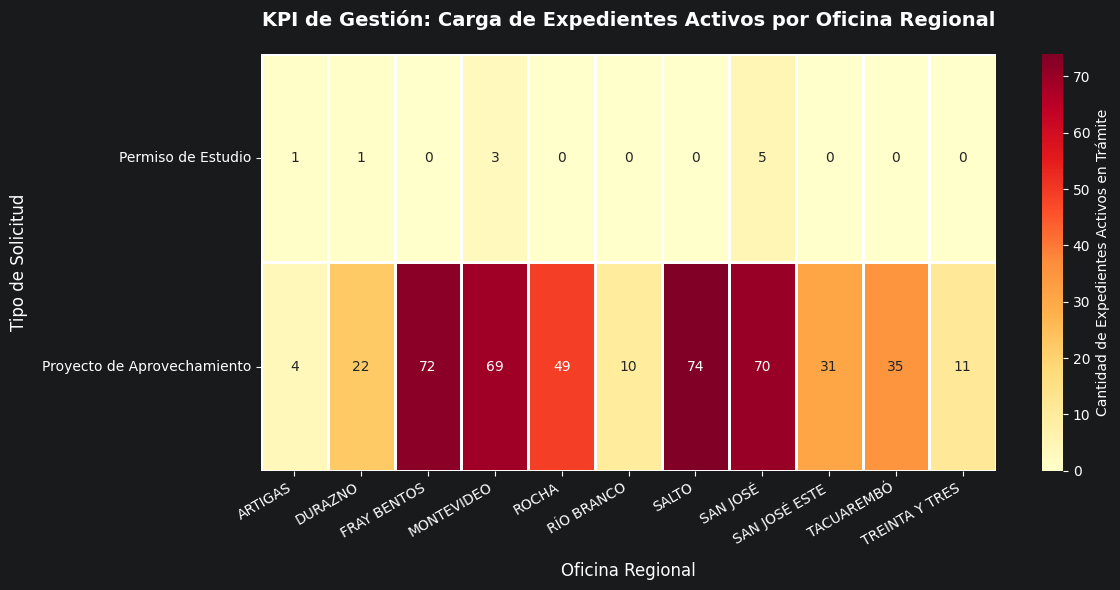

In [117]:
df['Regional'] = df['Regional'].astype(str).str.strip()
df['Tipo de Solicitud'] = df['Tipo de Solicitud'].astype(str).str.strip()

estados_activos = ['En Estudio', 'Pendiente de Resolución']
df_activos = df[df['Estado'].isin(estados_activos)]

matriz_regional = df_activos.pivot_table(
    index='Tipo de Solicitud',
    columns='Regional',
    values='Estado',
    aggfunc='count'
).fillna(0) # Rellenamos con 0 las combinaciones sin expedientes

# Configurar y diseñar el Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 6))

sns.heatmap(
    matriz_regional,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Cantidad de Expedientes Activos en Trámite'}
)

plt.title("KPI de Gestión: Carga de Expedientes Activos por Oficina Regional", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Oficina Regional", fontsize=12, labelpad=10)
plt.ylabel("Tipo de Solicitud", fontsize=12, labelpad=10)

# Rotar las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

# Ajustar los márgenes de forma automática para evitar cortes en los textos
plt.tight_layout()

# Guardar la gráfica en alta definición para informes o presentaciones
plt.savefig('mapa_calor_carga_regional.png', dpi=300)

# Mostrar el resultado final
plt.show()

La disparidad extrema entre regionales, por ejemplo, Salto con 74 expedientes frente a Artigas con solo 4, evidencia que el diseño de los procesos administrativos no puede ser homogéneo. Oficinas vecinas o de similar escala territorial enfrentan realidades de gestión completamente opuestas, lo que matemáticamente invalida cualquier indicador plano de rendimiento que evalúe a todas las regionales bajo la misma vara operativa.
Se entiende sería de valor el equilibrio de Personal Técnico, considerando esto para la distribución de estos.

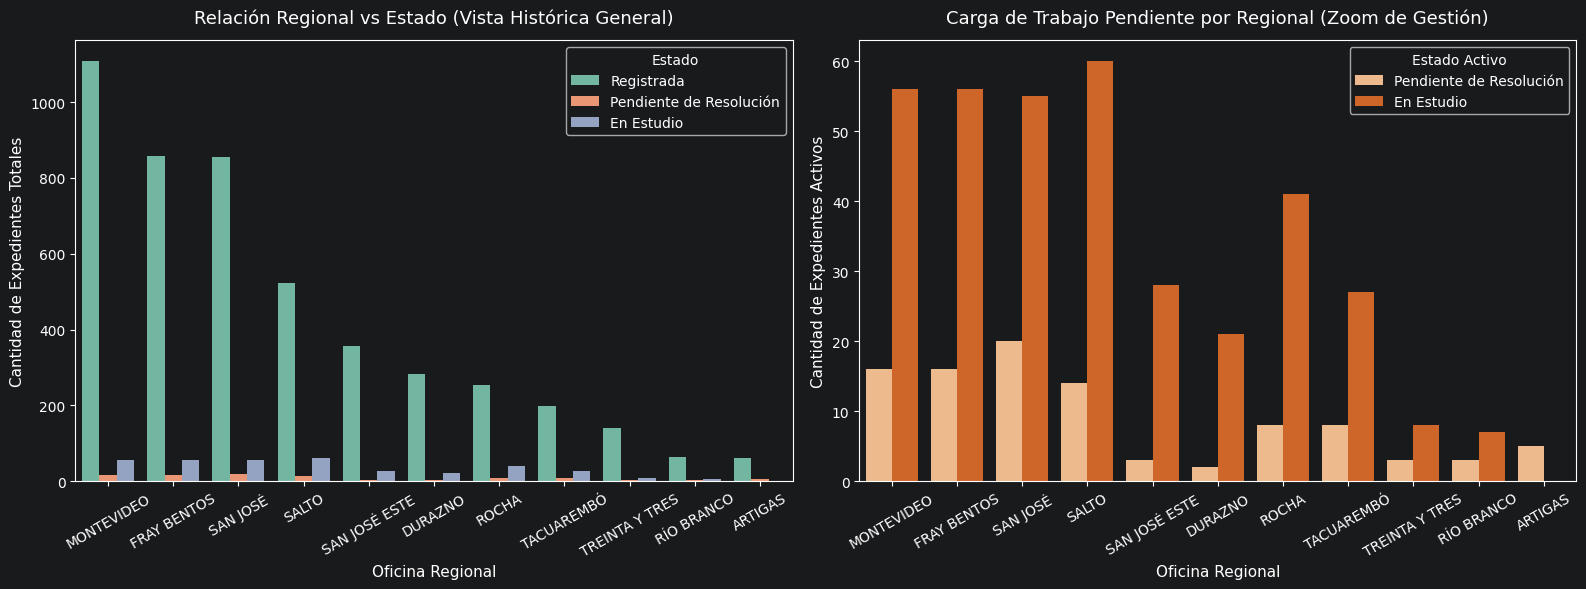

In [118]:
df['Regional'] = df['Regional'].astype(str).str.strip()
df['Estado'] = df['Estado'].astype(str).str.strip()

# Obtenemos el orden de las regionales (de mayor a menor volumen total)
orden_regionales = df['Regional'].value_counts().index

fig, axis = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1 Vista General Histórica
# Usamos 'hue' para cruzar la Regional con el Estado
sns.countplot(ax=axis[0], data=df, x='Regional', hue='Estado', order=orden_regionales, palette="Set2")
axis[0].set_title("Relación Regional vs Estado (Vista Histórica General)", fontsize=13, pad=12)
axis[0].set_xlabel("Oficina Regional", fontsize=11)
axis[0].set_ylabel("Cantidad de Expedientes Totales", fontsize=11)
axis[0].tick_params(axis='x', rotation=30) # Rotamos las letras para que no se encimen
axis[0].legend(title="Estado")

# GRÁFICO 2: Zoom de Gestión (Carga Activa Pendiente)
# Filtramos la base de datos para quitar las 'Registradas' y ver solo lo que está en proceso
df_pendientes = df[df['Estado'].isin(['En Estudio', 'Pendiente de Resolución'])]

sns.countplot(ax=axis[1], data=df_pendientes, x='Regional', hue='Estado', order=orden_regionales, palette="Oranges")
axis[1].set_title("Carga de Trabajo Pendiente por Regional (Zoom de Gestión)", fontsize=13, pad=12)
axis[1].set_xlabel("Oficina Regional", fontsize=11)
axis[1].set_ylabel("Cantidad de Expedientes Activos", fontsize=11)
axis[1].tick_params(axis='x', rotation=30)
axis[1].legend(title="Estado Activo")

# Ajuste automático de márgenes para evitar solapamientos de texto
plt.tight_layout()

# Guardar la composición
plt.savefig('relacion_regional_estado.png', dpi=300)

plt.show()

Mientras que el gráfico izquierdo muestra el acumulado de años de gestión, el gráfico derecho realiza un filtrado crítico: elimina las obras ya concluidas ("Registradas") para aislar únicamente los expedientes que se encuentran en proceso en las oficinas en este momento ("En Estudio" y "Pendiente de Resolución").

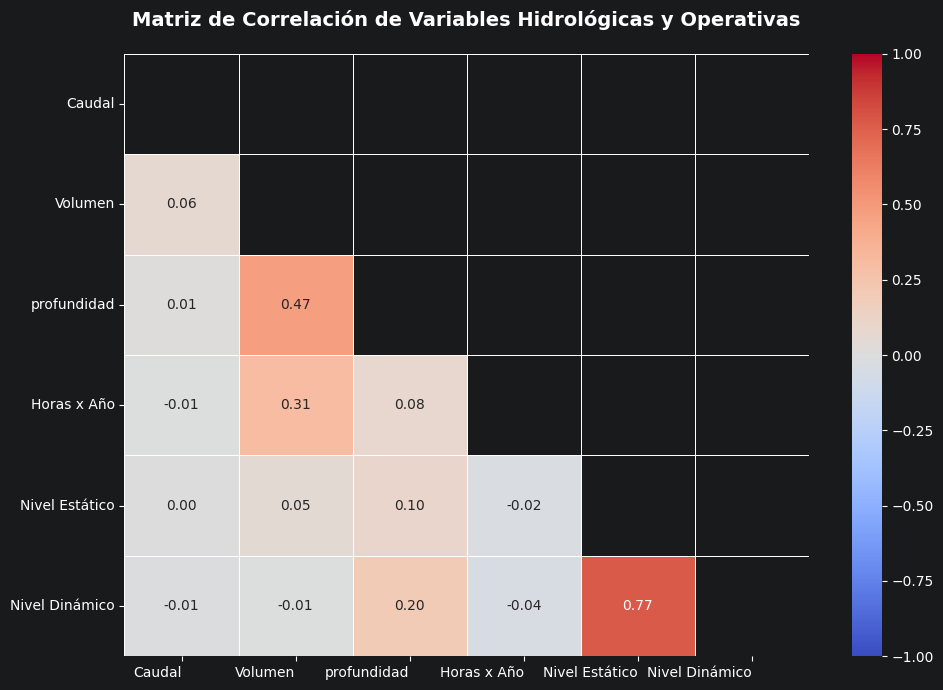

In [119]:
columnas_interes = ['Caudal', 'Volumen', 'profundidad', 'Horas x Año', 'Nivel Estático', 'Nivel Dinámico']

# Aseguramos la conversión de tipo de datos (reemplazando comas decimales por puntos)
for col in columnas_interes:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

# 3. Calcular la matriz de correlación lineal de Pearson
corr = df[columnas_interes].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))

sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

# Personalización estética
plt.title("Matriz de Correlación de Variables Hidrológicas y Operativas", fontsize=14, pad=20, fontweight='bold')
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('matriz_correlacion_hidrica.png', dpi=300)
plt.show()

Correlación Crítica: Nivel Estático vs. Nivel Dinámico
Es la relación más fuerte y estadísticamente significativa de todo el estudio (marcada en color rojo en la base de la matriz).
Explicación Hidráulica: Existe una dependencia lineal directa muy alta entre el nivel original del agua subterránea sin bombear (Nivel Estático) y el nivel alcanzado durante la explotación activa (Nivel Dinámico). Desde la perspectiva de la ingeniería hídrica, este valor ratifica la coherencia física de la base de datos: un acuífero con un nivel estático profundo demandará por defecto un nivel dinámico proporcionalmente más bajo bajo condiciones normales de bombeo.

Se concluye que los cuellos de botella detectados en las regionales son de naturaleza puramente administrativa y de distribución de carga laboral

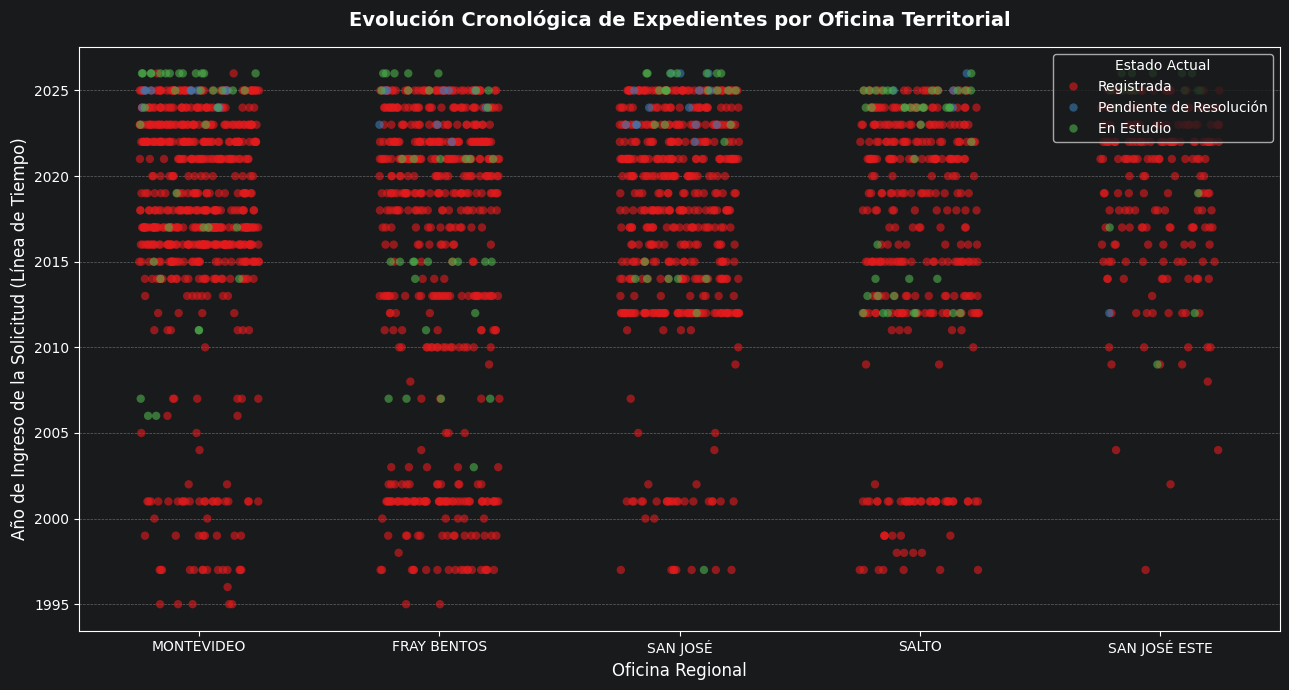

In [120]:
df['Fecha de Solicitud'] = pd.to_datetime(df['Fecha de Solicitud'], errors='coerce',format = 'mixed')
df['Anio_Solicitud'] = df['Fecha de Solicitud'].dt.year

df['Regional'] = df['Regional'].astype(str).str.strip()
top_regionales = df['Regional'].value_counts().head(5).index
df_filtrado = df[df['Regional'].isin(top_regionales)].dropna(subset=['Anio_Solicitud'])

plt.figure(figsize=(13, 7))

sns.stripplot(data=df_filtrado, x='Regional', y='Anio_Solicitud', hue='Estado',
              order=top_regionales, palette='Set1', size=6, alpha=0.6, jitter=0.25)

plt.title("Evolución Cronológica de Expedientes por Oficina Territorial", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Oficina Regional", fontsize=12)
plt.ylabel("Año de Ingreso de la Solicitud (Línea de Tiempo)", fontsize=12)
plt.legend(title="Estado Actual", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5) # Líneas guía horizontales
plt.tight_layout()

plt.savefig('cronologia_regional_estado.png', dpi=300)
plt.show()

Concentración Masiva Reciente (Período 2016 - 2026): La densidad de puntos en el gráfico se vuelve extremadamente compacta y continua a partir del año 2020, alcanzando su nivel más crítico y saturado entre 2024 y 2026. En esta franja superior, las observaciones (tanto expedientes concluidos como activos) están tan juntas que forman bloques sólidos de color, lo que demuestra un volumen de ingresos anuales muy superior al de las décadas pasadas.

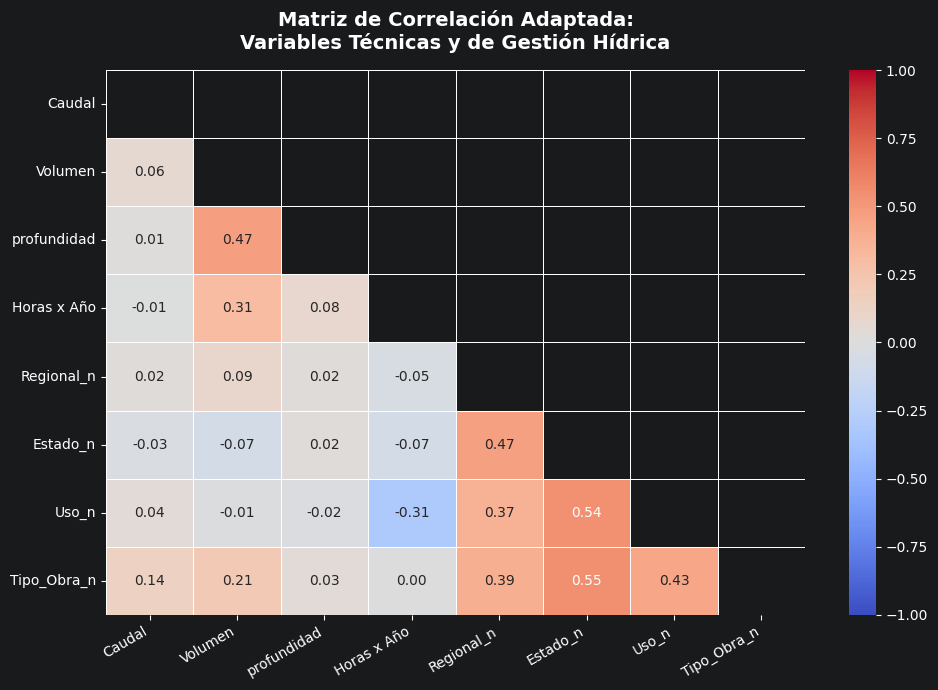

In [121]:
columnas_numericas = ['Caudal', 'Volumen', 'profundidad', 'Horas x Año']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

# Codificación de variables categóricas de texto a formato numérico
df['Regional_n'] = df['Regional'].astype(str).str.strip().astype('category').cat.codes
df['Estado_n'] = df['Estado'].astype(str).str.strip().astype('category').cat.codes
df['Uso_n'] = df['Uso'].astype(str).str.strip().astype('category').cat.codes
df['Tipo_Obra_n'] = df['Tipo de Obra'].astype(str).str.strip().astype('category').cat.codes

# Creamos la matriz seleccionando 4 numéricas y 4 categóricas codificadas
corr = df[["Caudal", "Volumen", "profundidad", "Horas x Año", "Regional_n", "Estado_n", "Uso_n", "Tipo_Obra_n"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))

sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Matriz de Correlación Adaptada:\nVariables Técnicas y de Gestión Hídrica", fontsize = 14, pad = 15, fontweight = 'bold')
plt.xticks(rotation = 30, ha = 'right')
plt.yticks(rotation = 0)

plt.tight_layout()

plt.savefig('matriz_correlacion_caso_hidrico.png', dpi=300)
plt.show()

La incorporación de variables categóricas codificadas (Regional, Estado, Uso y Tipo de Obra) en esta segunda matriz de correlación expande el diagnóstico desde el ámbito hidrogeológico hacia la ingeniería de procesos.
Se podría analizar si hay una relación entre el Estado y el Tipo de obra en determinados casos, pudiéndose consultar a los técnicos.

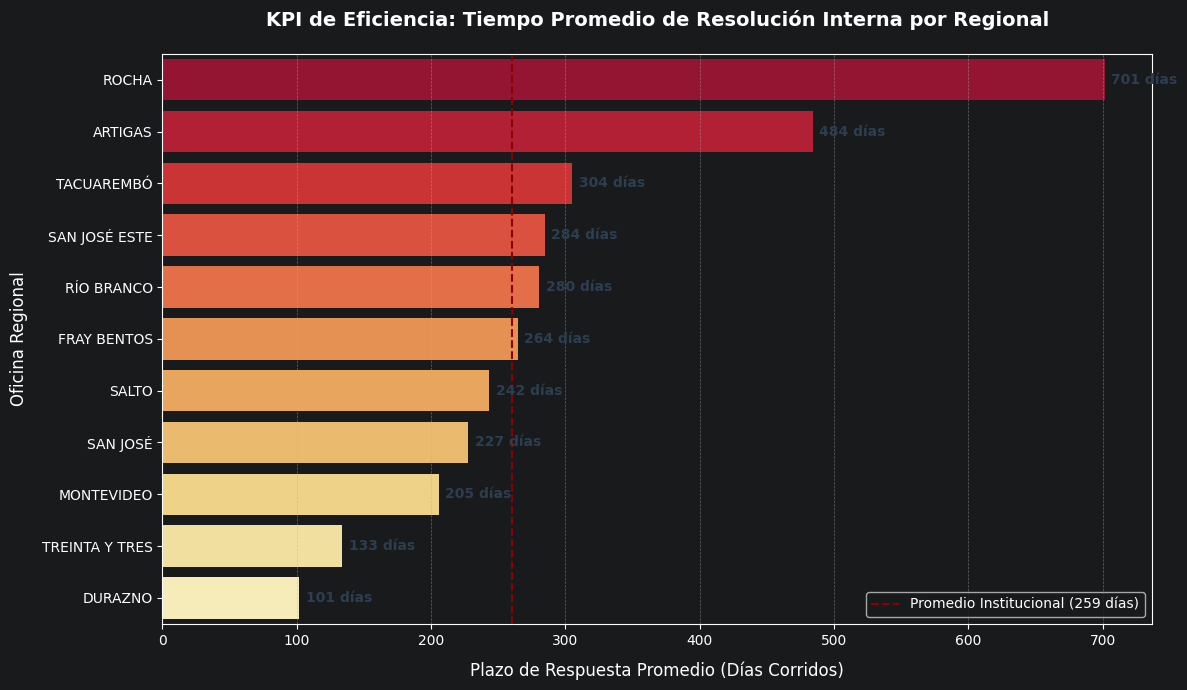

In [122]:
df['Fecha de Solicitud'] = pd.to_datetime(df['Fecha de Solicitud'], errors='coerce')
df['Fecha de Resolución'] = pd.to_datetime(df['Fecha de Resolución'], errors='coerce')

df_resueltos = df[(df['Estado'] == 'Registrada') &
                  (df['Fecha de Solicitud'].notna()) &
                  (df['Fecha de Resolución'].notna())].copy()

# Calculamos los días que tomó la tramitación interna
df_resueltos['Dias_Tramitacion'] = (df_resueltos['Fecha de Resolución'] - df_resueltos['Fecha de Solicitud']).dt.days

# Limpieza de valores atípicos o errores de registro (fechas invertidas)
df_resueltos = df_resueltos[df_resueltos['Dias_Tramitacion'] >= 0]

# Asegurar limpieza de nombres en las Regionales
df_resueltos['Regional'] = df_resueltos['Regional'].astype(str).str.strip()

analisis_regional = df_resueltos.groupby('Regional')['Dias_Tramitacion'].mean().reset_index()
analisis_regional = analisis_regional.sort_values(by='Dias_Tramitacion', ascending=False)
plt.figure(figsize=(12, 7))

sns.barplot(
    data=analisis_regional,
    x='Dias_Tramitacion',
    y='Regional',
    palette='YlOrRd_r',
    hue='Regional',
    legend=False
)

# Línea guía vertical que represente el promedio general de toda la institución
promedio_general = df_resueltos['Dias_Tramitacion'].mean()
plt.axvline(promedio_general, color='darkred', linestyle='--', linewidth=1.5,
            label=f'Promedio Institucional ({int(promedio_general)} días)')

plt.title("KPI de Eficiencia: Tiempo Promedio de Resolución Interna por Regional", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Plazo de Respuesta Promedio (Días Corridos)", fontsize=12, labelpad=10)
plt.ylabel("Oficina Regional", fontsize=12, labelpad=10)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)

for index, value in enumerate(analisis_regional['Dias_Tramitacion']):
    plt.text(value + 5, index, f"{int(value)} días",
             va='center', ha='left', fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout()

plt.savefig('../kpi_gestion_tiempos_por_regional.png', dpi=300)
plt.show()

La evaluación integrada de este KPI rompe con la intuición y aporta las pruebas definitivas para la reingeniería de procesos se venía planteando en el informe:
Los datos prueban que acumulación de expedientes no es sinónimo de lentitud. Salto y Fray Bentos están congestionadas porque les entran muchísimos trámites, pero su personal técnico trabaja a una velocidad de resolución superior a la media. El verdadero problema está en las oficinas de Rocha y Artigas. Es prioritario intervenir operativamente la regional de Rocha para identificar si el retraso de 701 días responde a expedientes históricos no archivados o a cuellos de botella en la firma de resoluciones.

In [123]:
df.shape[0]

5700

In [124]:
len(df)

5700

In [125]:
df.isnull().sum()

Tipo de Solicitud                 541
Nro. GEX                          543
Fecha Vencimiento                1000
Estado                            541
Regional                          543
Departamento                      543
Tecnicos                          558
Fecha de Solicitud               2701
Fecha de Resolución              2944
Fecha de Inscripción             1047
Caudal                            587
Volumen                           573
Uso                               541
Destino                           541
Latitud                           541
Longitud                          541
Mes Inicio                        577
Mes Final                         577
Horas x Año                       579
Depto.-Padrón                     555
Tipo de Obra                      542
Id Solicitud                      541
Codigo Cuencas de nivel 5         548
Sección y localidad catastral    2313
Cuencas de nivel 3                548
Curso a Utilizar                 3125
Tipo de acui

In [126]:
df.isnull().sum() / df.shape[0]

Tipo de Solicitud                0.094912
Nro. GEX                         0.095263
Fecha Vencimiento                0.175439
Estado                           0.094912
Regional                         0.095263
Departamento                     0.095263
Tecnicos                         0.097895
Fecha de Solicitud               0.473860
Fecha de Resolución              0.516491
Fecha de Inscripción             0.183684
Caudal                           0.102982
Volumen                          0.100526
Uso                              0.094912
Destino                          0.094912
Latitud                          0.094912
Longitud                         0.094912
Mes Inicio                       0.101228
Mes Final                        0.101228
Horas x Año                      0.101579
Depto.-Padrón                    0.097368
Tipo de Obra                     0.095088
Id Solicitud                     0.094912
Codigo Cuencas de nivel 5        0.096140
Sección y localidad catastral    0

In [127]:
df.isnull().sum().sort_values(ascending=False)

Producción                       3898
Curso a Utilizar                 3125
Fecha de Resolución              2944
Fecha de Solicitud               2701
Anio_Solicitud                   2701
Tipo de acuifero                 2572
Sección y localidad catastral    2313
Fecha de Inscripción             1047
Nivel Dinámico                   1045
Tipo Resolución                  1007
Fecha Vencimiento                1000
Nivel Estático                    892
Caudal Ensayado                   728
Diámetro                          605
Caudal                            587
profundidad                       585
Horas x Año                       579
Mes Inicio                        577
Mes Final                         577
Volumen                           573
Tecnicos                          558
Depto.-Padrón                     555
Codigo Cuencas de nivel 5         548
Codigo Cuencas de nivel 2         548
Cuencas de nivel 3                548
Nro. GEX                          543
Departamento

In [128]:
df.isnull().sum().sort_values(ascending=False) / len(df)

Producción                       0.683860
Curso a Utilizar                 0.548246
Fecha de Resolución              0.516491
Fecha de Solicitud               0.473860
Anio_Solicitud                   0.473860
Tipo de acuifero                 0.451228
Sección y localidad catastral    0.405789
Fecha de Inscripción             0.183684
Nivel Dinámico                   0.183333
Tipo Resolución                  0.176667
Fecha Vencimiento                0.175439
Nivel Estático                   0.156491
Caudal Ensayado                  0.127719
Diámetro                         0.106140
Caudal                           0.102982
profundidad                      0.102632
Horas x Año                      0.101579
Mes Inicio                       0.101228
Mes Final                        0.101228
Volumen                          0.100526
Tecnicos                         0.097895
Depto.-Padrón                    0.097368
Codigo Cuencas de nivel 5        0.096140
Codigo Cuencas de nivel 2        0

Al realizar el análisis exploratorio de datos (EDA), se evidencia una limitación estructural crítica: un volumen significativo de registros presenta datos incompletos o nulos en variables operativas e hidrogeológicas clave.
Esta falta de completitud penaliza la representatividad de los modelos de correlación y los KPI de eficiencia calculados. En la gestión pública del recurso hídrico, un dato ausente suele ser el reflejo de dos fallas operativas: o bien el solicitante omitió declarar la información técnica por falta de rigurosidad en los formularios, o el organismo no cuenta con mecanismos automatizados de validación al momento del ingreso del trámite.

Entendemos que se requiere un seguimiento mayor en la captación de datos!!

In [129]:
df['Producción'] = pd.to_numeric(df['Producción'].astype(str).str.replace(',', '.'), errors='coerce')
df['Tipo de acuifero'] = df['Tipo de acuifero'].astype(str).str.strip()
df['Curso a Utilizar'] = df['Curso a Utilizar'].astype(str).str.strip()

# Reemplazamos los nulos por la MEDIANA en la variable numérica (Producción)
df["Producción"] = df["Producción"].fillna(df["Producción"].median())

# Reemplazamos los nulos por la MODA en la variable categórica (Tipo de acuífero)
df["Tipo de acuifero"] = df["Tipo de acuifero"].fillna(df["Tipo de acuifero"].mode()[0])

# Al ser texto, reemplazamos por la MODA (el curso de agua más repetido)
df["Curso a Utilizar"] = df["Curso a Utilizar"].fillna(df["Curso a Utilizar"].mode()[0])

# Verificar que ya no queden valores nulos en estas columnas
print(df[["Producción", "Tipo de acuifero", "Curso a Utilizar"]].isna().sum())

Producción          0
Tipo de acuifero    0
Curso a Utilizar    0
dtype: int64


In [130]:
RUTA_PROCESSED = '../data/processed/Base_de_datos_Python_GRUPO A.csv'

In [131]:
df.to_csv(RUTA_PROCESSED, index = False,sep = ';', encoding = 'utf-8')
print('Archivos procesados:')
print(RUTA_PROCESSED)

Archivos procesados:
../data/processed/Base_de_datos_Python_GRUPO A.csv


**Recomendaciones y Conclusiones**
Generar un sistema digital para que se completen todos los datos para lograr el registro
Se podrían realizar autorizaciones más automáticas para los casos estandar y dejar en mano de técnicos esecializados para las complejas
Hacer un seguimiento de cuántos pozos existen sin autorización
Hacer transparente los kpi de gestión para mostrar a todo el equipo la problemática
Esperamos que estos análisis puedan ser de ayuda a las compañeras que trabajan en el área, y los datos colaboren a una mejora significativa, aplicada a la realidad de los sistemas de gestión hídrica del país!